# Домашнее задание №4: Задача регрессии

### Вопросы и задания:
1. Что представляет из себя разведочный анализ данных?
2. Какая основная библиотека Python используется для анализа данных этим способом?
3. Опишите своими словами процесс анализа данных в соответствии с тем, что рассказывает спикер.
4. Решите задачу, предложенную спикером.
5. Что представляет из себя процесс ETL?

### Процесс выполнения:

1. Разведочный анализ данных – это предварительное исследование датасета с целью определения его основных характеристик, взаимосвязей между признаками, а также для сужения набора методов, используемых для создания модели машинного обучения. Ведь чем проще модель, тем легче её обучить и интерпретировать полученные результаты.

2. Сейчас самой объёмной и полной библиотекой является Pandas profiling.

3. и 4. Данные другие, но действия те же

In [37]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import rcParams
rcParams['figure.figsize'] = 16, 8
pd.set_option("display.max_columns", None)

In [38]:
data = pd.read_csv('./data/SouthGermanCredit.asc', sep=r"\s+")
# Словарь переименования столбцов
column_mapping = {
    "laufkont": "статус_счёта",
    "laufzeit": "срок_кредита",
    "moral": "кредитная_история",
    "verw": "цель_кредита",
    "hoehe": "сумма_кредита",
    "sparkont": "сбережения",
    "beszeit": "стаж_работы",
    "rate": "размер_платежа",
    "famges": "семейное_положение",
    "buerge": "поручители",
    "wohnzeit": "срок_проживания",
    "verm": "имущество",
    "alter": "возраст",
    "weitkred": "другие_кредиты",
    "wohn": "жильё",
    "bishkred": "количество_кредитов",
    "beruf": "работа",
    "pers": "иждивенцы",
    "telef": "телефон",
    "gastarb": "иностранный_работник",
    "kredit": "кредитный_риск"
}

# Переименовываем столбцы
data = data.rename(columns=column_mapping)

print(data.head())

   статус_счёта  срок_кредита  кредитная_история  цель_кредита  сумма_кредита  \
0             1            18                  4             2           1049   
1             1             9                  4             0           2799   
2             2            12                  2             9            841   
3             1            12                  4             0           2122   
4             1            12                  4             0           2171   

   сбережения  стаж_работы  размер_платежа  семейное_положение  поручители  \
0           1            2               4                   2           1   
1           1            3               2                   3           1   
2           2            4               2                   2           1   
3           1            3               3                   3           1   
4           1            3               4                   3           1   

   срок_проживания  имущество  возраст  друг

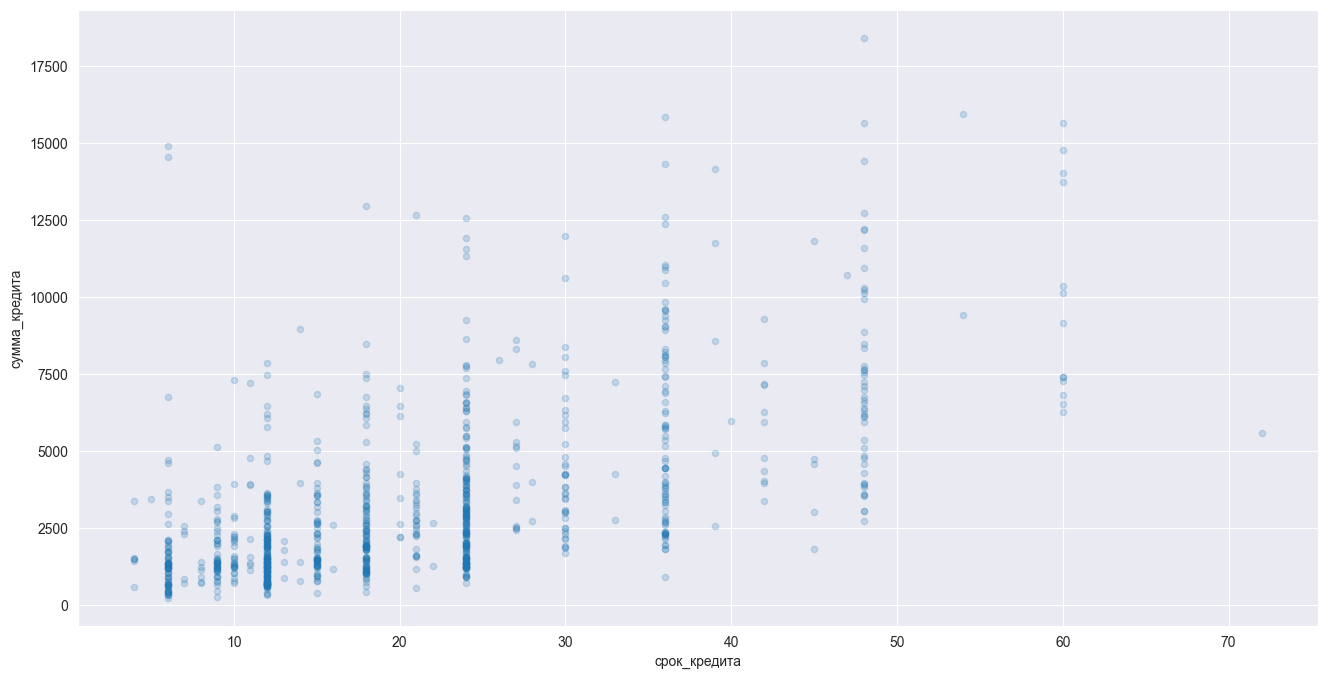

In [39]:
data.plot.scatter(x="срок_кредита", y="сумма_кредита", alpha=0.2)
plt.show()

### Исследование данных
Используем pandas describe для первичного анализа данных

In [40]:
data.describe()

,статус_счёта,срок_кредита,кредитная_история,цель_кредита,сумма_кредита,сбережения,стаж_работы,размер_платежа,семейное_положение,поручители,срок_проживания,имущество,возраст,другие_кредиты,жильё,количество_кредитов,работа,иждивенцы,телефон,иностранный_работник,кредитный_риск
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,1.145000,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.845000,1.404000,1.963000,0.700000
std,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856,0.458487
min,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,1.000000,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000
50%,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,1.000000,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000
75%,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,1.000000,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,3.000000,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000


### Пропуски и аномалии

In [41]:
# Базовая статистика
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   статус_счёта          1000 non-null   int64
 1   срок_кредита          1000 non-null   int64
 2   кредитная_история     1000 non-null   int64
 3   цель_кредита          1000 non-null   int64
 4   сумма_кредита         1000 non-null   int64
 5   сбережения            1000 non-null   int64
 6   стаж_работы           1000 non-null   int64
 7   размер_платежа        1000 non-null   int64
 8   семейное_положение    1000 non-null   int64
 9   поручители            1000 non-null   int64
 10  срок_проживания       1000 non-null   int64
 11  имущество             1000 non-null   int64
 12  возраст               1000 non-null   int64
 13  другие_кредиты        1000 non-null   int64
 14  жильё                 1000 non-null   int64
 15  количество_кредитов   1000 non-null   int64
 16  работа            

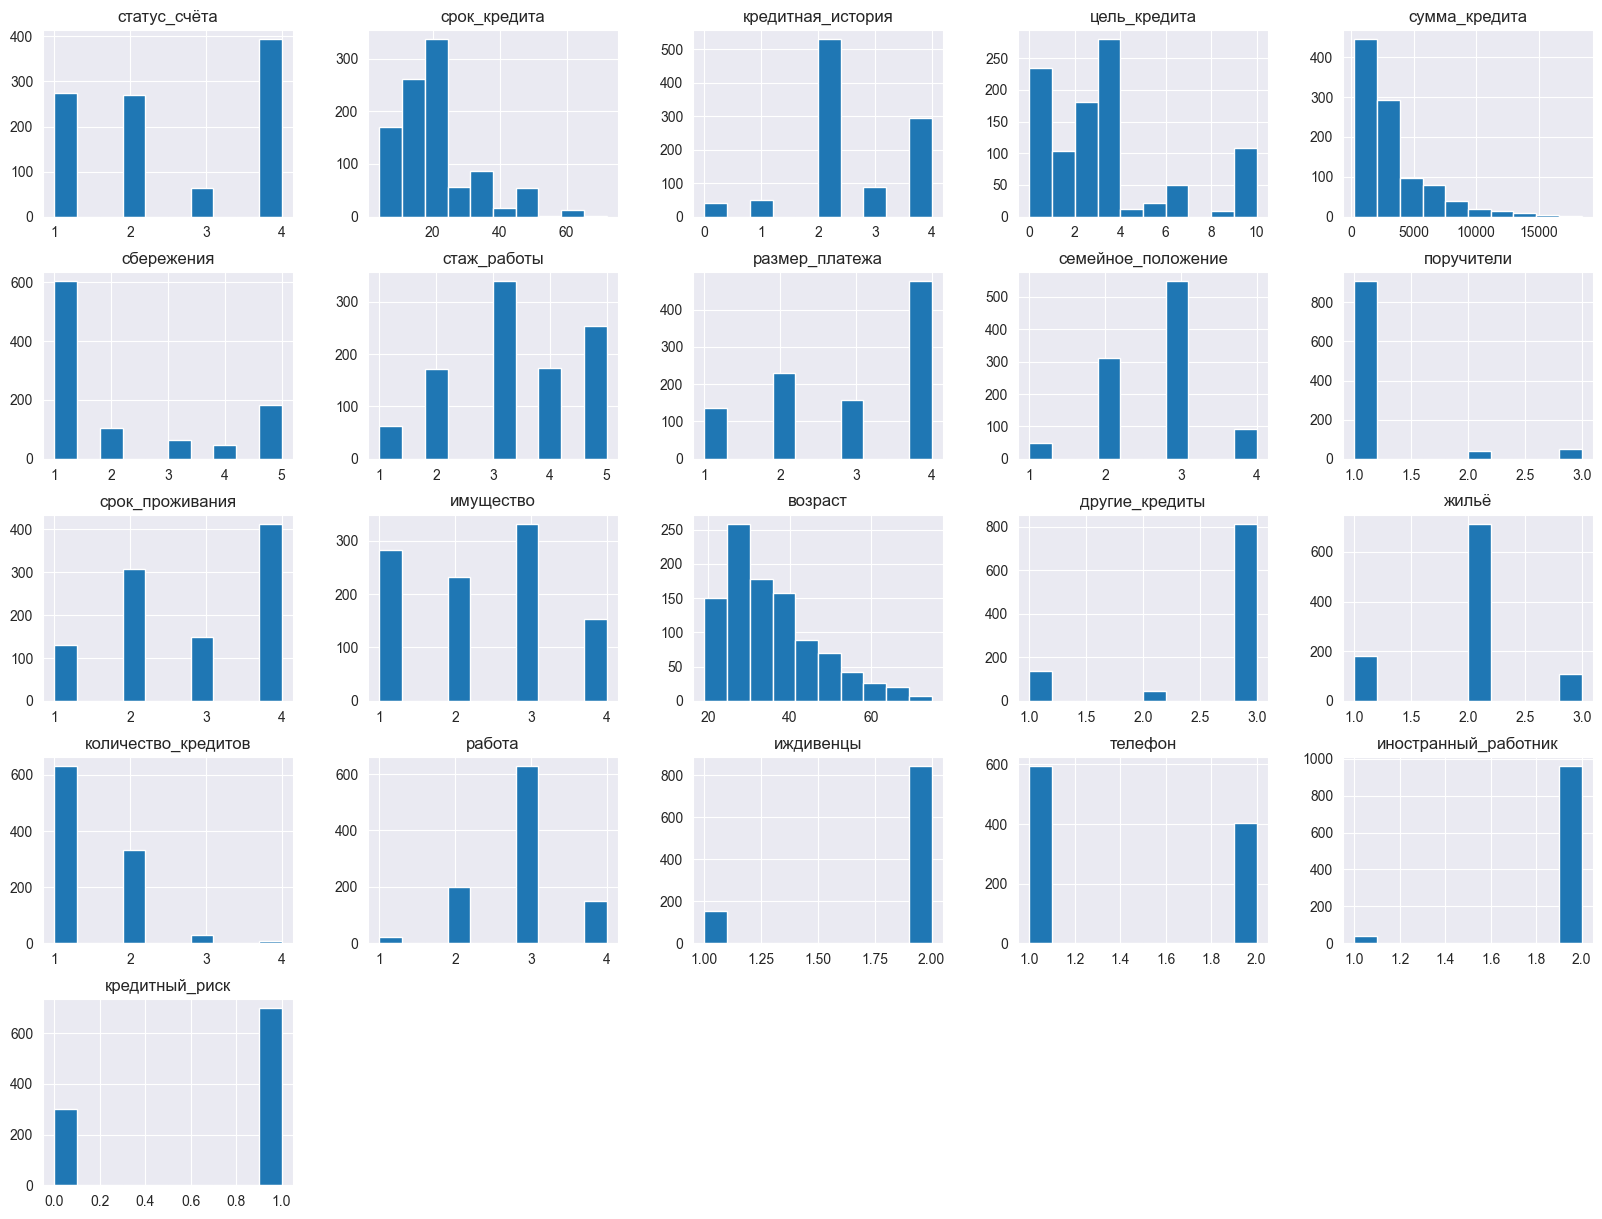

In [42]:
# Гистограммы всех числовых колонок
data.hist(figsize=(20, 15))
plt.show()

### Корреляционная матрица

In [43]:
corr = data.corr()
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = pairs.stack().abs().sort_values(ascending=False).head(5)
print(pairs)

срок_кредита       сумма_кредита          0.624988
кредитная_история  количество_кредитов    0.437066
работа             телефон                0.383022
статус_счёта       кредитный_риск         0.350847
имущество          жильё                  0.342969
dtype: float64


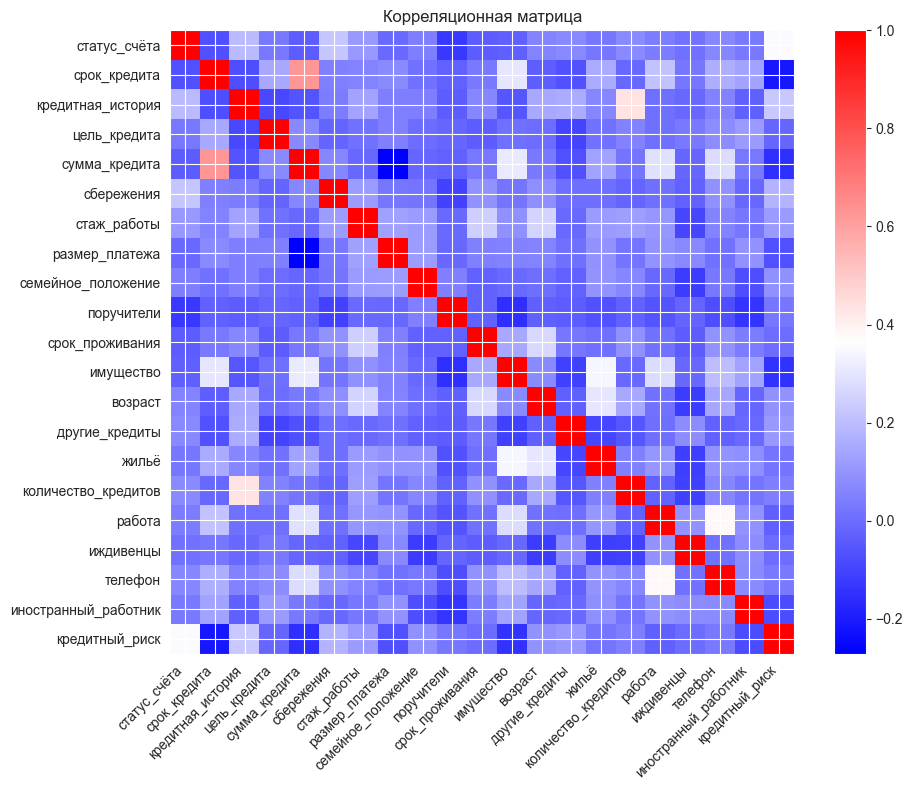

In [44]:
plt.figure(figsize=(10, 8))
plt.imshow(data.corr(), cmap='bwr')
plt.colorbar()
plt.xticks(range(len(data.columns)), data.columns, rotation=45, ha='right')
plt.yticks(range(len(data.columns)), data.columns)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

### Выбросы

<Axes: >

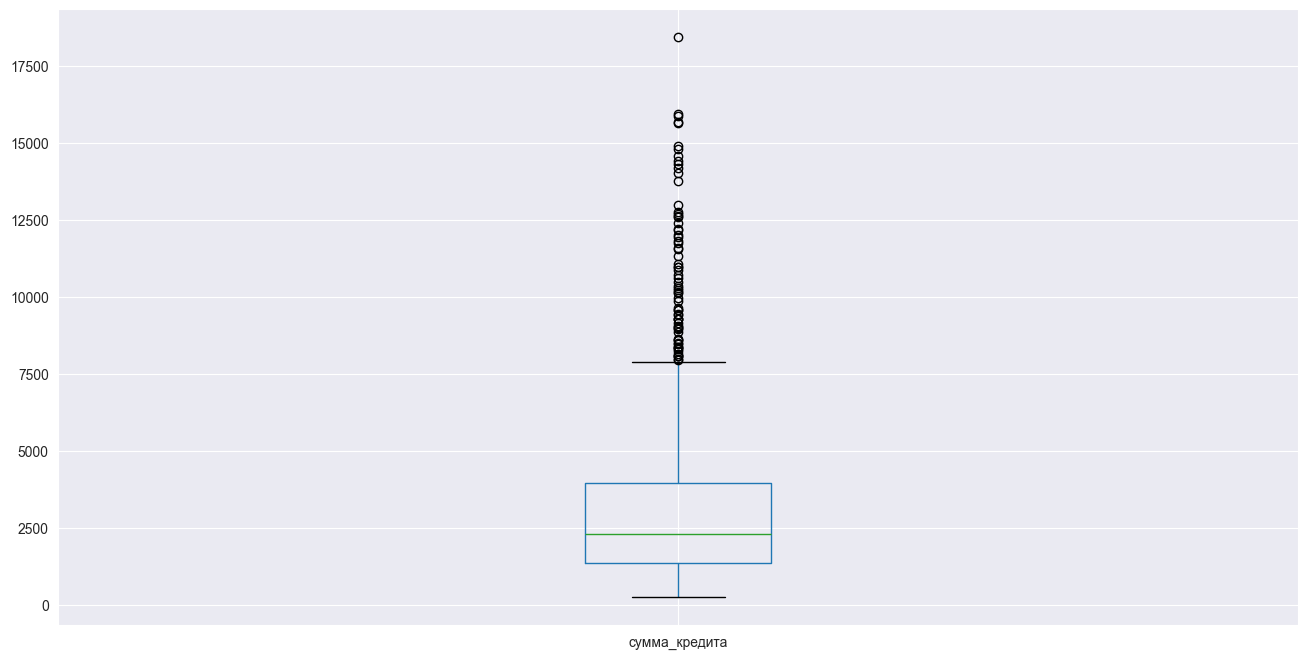

In [45]:
data.boxplot(column="сумма_кредита")

<Axes: >

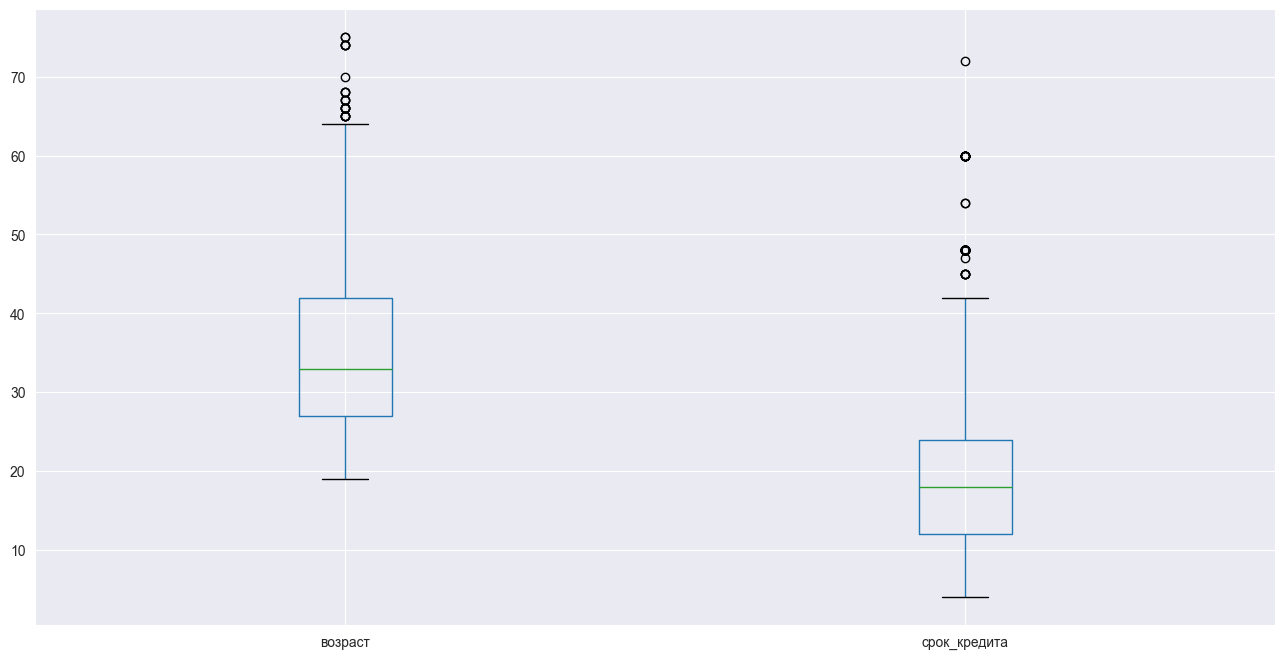

In [46]:
data.boxplot(column=["возраст", "срок_кредита"])

Но так как это кредиты, здесь все выбросы это просто состоятельные клиенты или особые условия на которые пошёл банк. Убирать или преобразовывать ничего не будем.